# M4: parametric surface fit for trough localization

The 10x10 grid is coarse and individual subjects are noisy -- `analysis.
trough_location`'s grid argmin (M2) can only ever land exactly on one of the
100 sampled points. This notebook fits a continuous surface to each
subject's mean grid and locates *that* surface's minimum instead, which can
fall between grid points and is less sensitive to a single noisy pixel.

Two methods (your choice: implement both, exposed as `method=`):
- **paraboloid** -- linear least squares, closed-form, no initial guess.
- **gaussian** -- an inverted 2D Gaussian dip, nonlinear least squares
  (`scipy.optimize.curve_fit`), initialized from the grid argmin.

Both report `fit_valid`: False if the fit didn't converge, isn't actually a
minimum (paraboloid: not positive-definite; gaussian: non-positive
amplitude), or falls outside the sampled red/green range.

In [1]:
import sys
sys.path.append('../scripts')

import matplotlib.pyplot as plt
import pandas as pd

from analysis import load_runmap, load_baselines, load_metadata, load_grid_axes, mean_grid, trough_location, fit_trough_surface, DEFAULT_NORMALIZE
import plotting as pl

runmap_df = load_runmap()
baselines_df = load_baselines()
metadata_df = load_metadata()
red_vals, green_vals = load_grid_axes()

SESSION = 1

## One subject: argmin vs. both fits
`MET000` -- the same subject used throughout every prior notebook.

    argmin: red=2133, green=889, depth=0.048
paraboloid: red=1708, green=764, depth=0.471, r2=0.70
  gaussian: red=1782, green=772, depth=0.269, r2=0.60


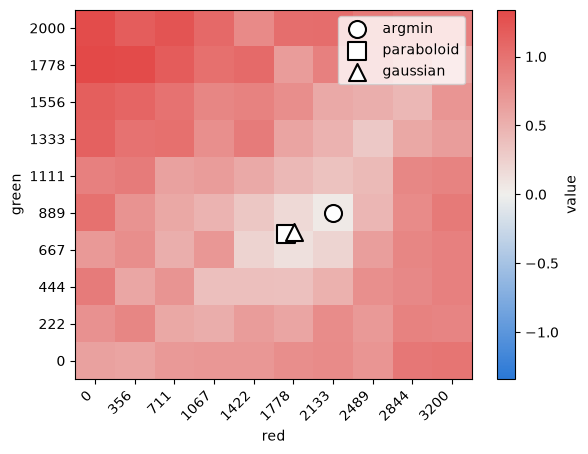

In [2]:
grid = mean_grid(runmap_df, baselines_df, 'MET000', SESSION, normalize=DEFAULT_NORMALIZE)
locations = {
    'argmin': trough_location(grid, red_vals, green_vals),
    'paraboloid': fit_trough_surface(grid, red_vals, green_vals, method='paraboloid'),
    'gaussian': fit_trough_surface(grid, red_vals, green_vals, method='gaussian'),
}
for name, loc in locations.items():
    print(f"{name:>10}: red={loc['red']:.0f}, green={loc['green']:.0f}, depth={loc['depth']:.3f}"
          + (f", r2={loc['r_squared']:.2f}" if 'r_squared' in loc else ''))
pl.plot_trough_locations(grid, locations);

## Ragged session (3 runs): still works
`MET037` (group `PD`) -- `mean_grid` already averages over however many runs
exist, so the fit needs no special handling here.

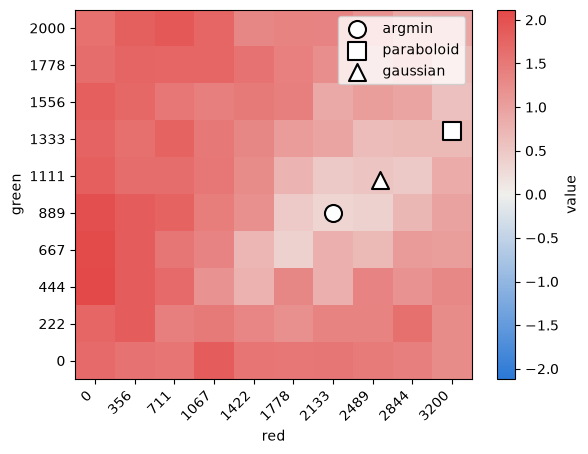

In [3]:
ragged_grid = mean_grid(runmap_df, baselines_df, 'MET037', SESSION, normalize=DEFAULT_NORMALIZE)
ragged_locations = {
    'argmin': trough_location(ragged_grid, red_vals, green_vals),
    'paraboloid': fit_trough_surface(ragged_grid, red_vals, green_vals, method='paraboloid'),
    'gaussian': fit_trough_surface(ragged_grid, red_vals, green_vals, method='gaussian'),
}
pl.plot_trough_locations(ragged_grid, ragged_locations);

## Across all subjects: fit quality and agreement with argmin
`subject_troughs.csv` (rebuilt by `scripts/build_troughs.py`) now carries
both the argmin columns (`red`/`green`/`depth`) and the paraboloid fit's
columns (`fitted_red`/`fitted_green`/`fitted_depth`/`fitted_r_squared`/
`fitted_valid`) side by side.

fit_valid: 37 / 62


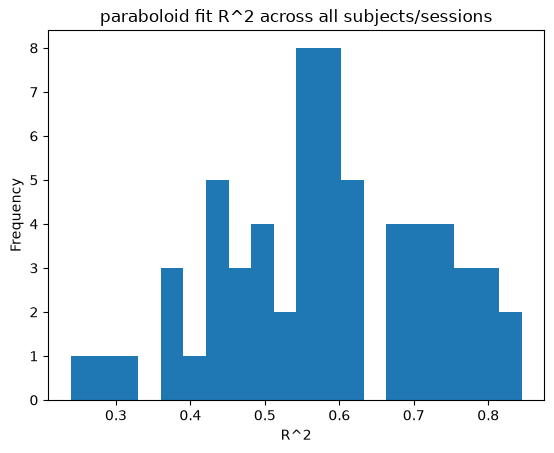

In [4]:
troughs_df = pd.read_csv('../files/subject_troughs.csv', keep_default_na=False)
print(f"fit_valid: {troughs_df['fitted_valid'].sum()} / {len(troughs_df)}")
troughs_df['fitted_r_squared'].plot(kind='hist', bins=20, title='paraboloid fit R^2 across all subjects/sessions');
plt.xlabel('R^2');

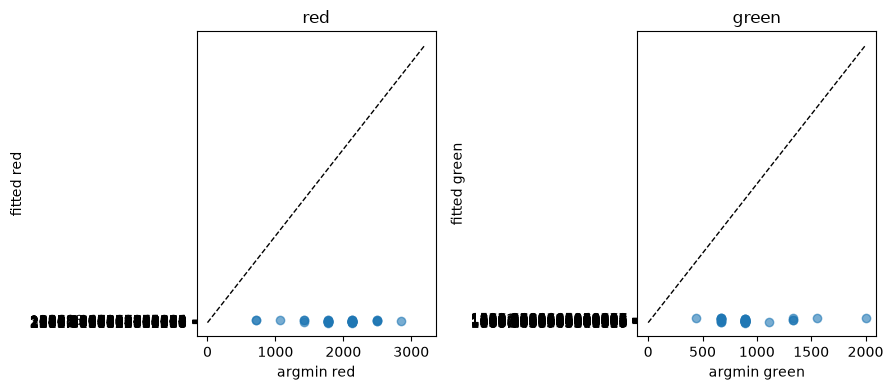

In [5]:
valid = troughs_df[troughs_df['fitted_valid']]
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(valid['red'], valid['fitted_red'], alpha=0.6)
axes[0].plot([0, 3200], [0, 3200], 'k--', linewidth=1)
axes[0].set_xlabel('argmin red'); axes[0].set_ylabel('fitted red'); axes[0].set_title('red')
axes[1].scatter(valid['green'], valid['fitted_green'], alpha=0.6)
axes[1].plot([0, 2000], [0, 2000], 'k--', linewidth=1)
axes[1].set_xlabel('argmin green'); axes[1].set_ylabel('fitted green'); axes[1].set_title('green')
fig.tight_layout()

## Notes
- The fitted surface's minimum *value* is often notably higher than the
  observed grid's minimum pixel (e.g. `MET000`: argmin depth ~0.05 vs.
  paraboloid ~0.47) -- **expected, not a bug**: the trough was already
  established (M1) as broad and flat, not a sharp bowl, so a smooth
  quadratic's best-fit vertex doesn't need to coincide with the single
  noisiest/most extreme sampled pixel. `r_squared` (moderate, ~0.6-0.75 for
  most subjects) quantifies how well the paraboloid actually describes the
  shape; `fitted_valid` flags fits where the surface didn't produce a
  sensible in-bounds minimum at all.
- `fit_trough_surface(..., method=)` and `subject_troughs(...,
  surface_method=)` both take `'paraboloid'` or `'gaussian'` -- the
  persisted CSV uses `'paraboloid'` by default (more numerically stable);
  pass `surface_method='gaussian'` to `subject_troughs` for the alternative.